<a href="https://colab.research.google.com/github/sujitx-vs/Customer_Churn_Project/blob/main/Day11_PML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris

In [ ]:
x,y = load_iris(return_X_y=True) # x will get the all the columns and the target column will be in y

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
model = LogisticRegression()

In [ ]:
scores = []

In [ ]:
for train_index, val_index in kf.split(x):
    x_train, x_test = x[train_index], x[val_index]
    y_train, y_test = y[train_index], y[val_index]
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

print("Accuracy ",scores)
print("Avg Accuracy ", np.mean(scores))

Accuracy  [1.0, 1.0, 0.9333333333333333, 0.9666666666666667, 0.9666666666666667]
Avg Accuracy  0.9733333333333334


In [ ]:
from sklearn.datasets import make_blobs

x,y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

In [ ]:
df = pd.DataFrame(x, columns=['feature x1', 'feature x2'])

In [ ]:
df

,feature x1,feature x2
0,0.836857,2.136359
1,-1.413658,7.409623
2,1.155213,5.099619
3,-1.018616,7.814915
4,1.271351,1.892542
...,...,...
295,1.973698,1.579798
296,2.518342,1.391766
297,0.438990,4.535929
298,0.369479,7.791105


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature x1  300 non-null    float64
 1   feature x2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


In [ ]:
df.describe()

,feature x1,feature x2
count,300.000000,300.000000
mean,-0.006328,3.967821
std,1.636000,2.593963
min,-3.122407,-0.765892
25%,-1.498837,1.916025
50%,-0.044497,3.529012
75%,1.433350,5.607633
max,3.437618,9.282932


<Axes: xlabel='feature x1', ylabel='feature x2'>

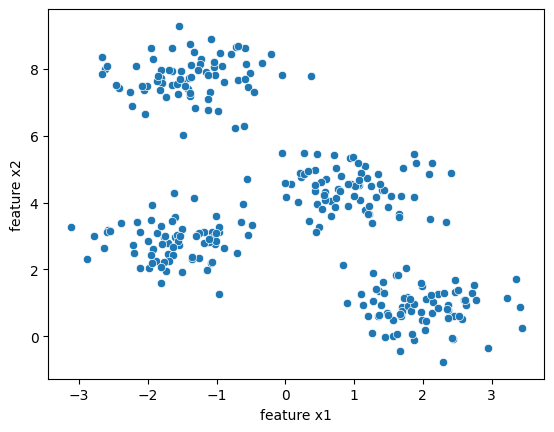

In [ ]:
sns.scatterplot(data=df, x='feature x1', y='feature x2')

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x = sc.fit_transform(x)

Elbow method

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
inertia =[]

for k in range(1,10):
  kmeans = KMeans(n_clusters=k, random_state=0)
  kmeans.fit(x)
  inertia.append(kmeans.inertia_)

NameError: name 'x' is not defined

Text(0, 0.5, 'Inertia')

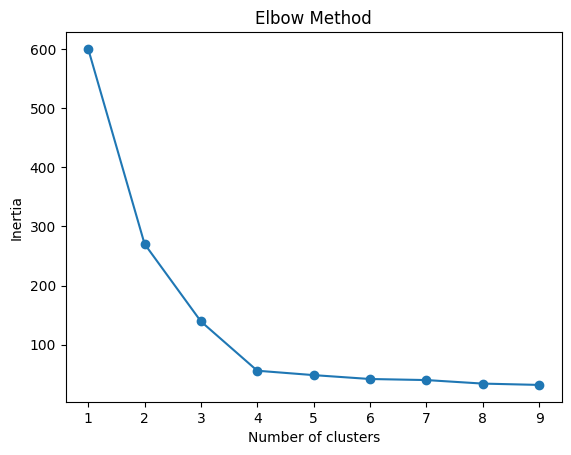

In [ ]:
plt.plot(range(1,10), inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=0)
y_pred = kmeans.fit(x)

In [ ]:
df['Cluster'] = kmeans.predict(x)

In [ ]:
centers = kmeans.cluster_centers_

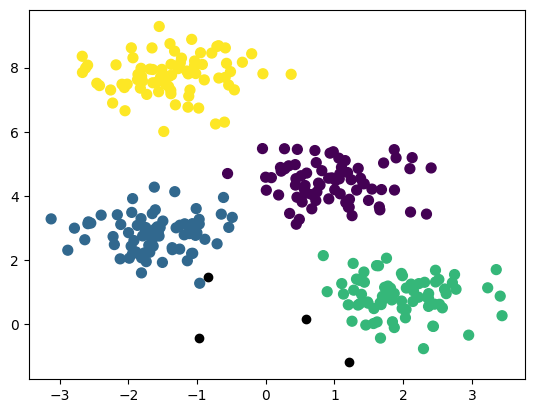

In [ ]:
plt.scatter(df['feature x1'], df['feature x2'], c=df['Cluster'], cmap='viridis',s=50)
plt.scatter(centers[:,0], centers[:,1], color='black')

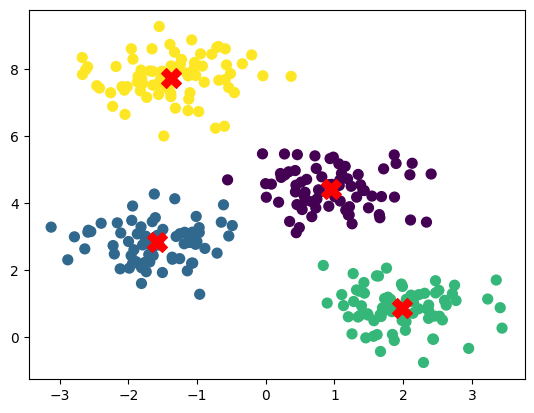

In [ ]:
plt.scatter(df['feature x1'], df['feature x2'], c=df['Cluster'], cmap='viridis',s=50)
center_originals = sc.inverse_transform(centers)
plt.scatter(center_originals[:,0], center_originals[:,1], color='red',s=200,marker='X')

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
score = silhouette_score(x, df['Cluster'])
score

np.float64(0.6569234398199433)

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
data = load_iris()

In [ ]:
iris_data = load_iris(as_frame = True) # load full data

iris = iris_data.frame # load as dataframe

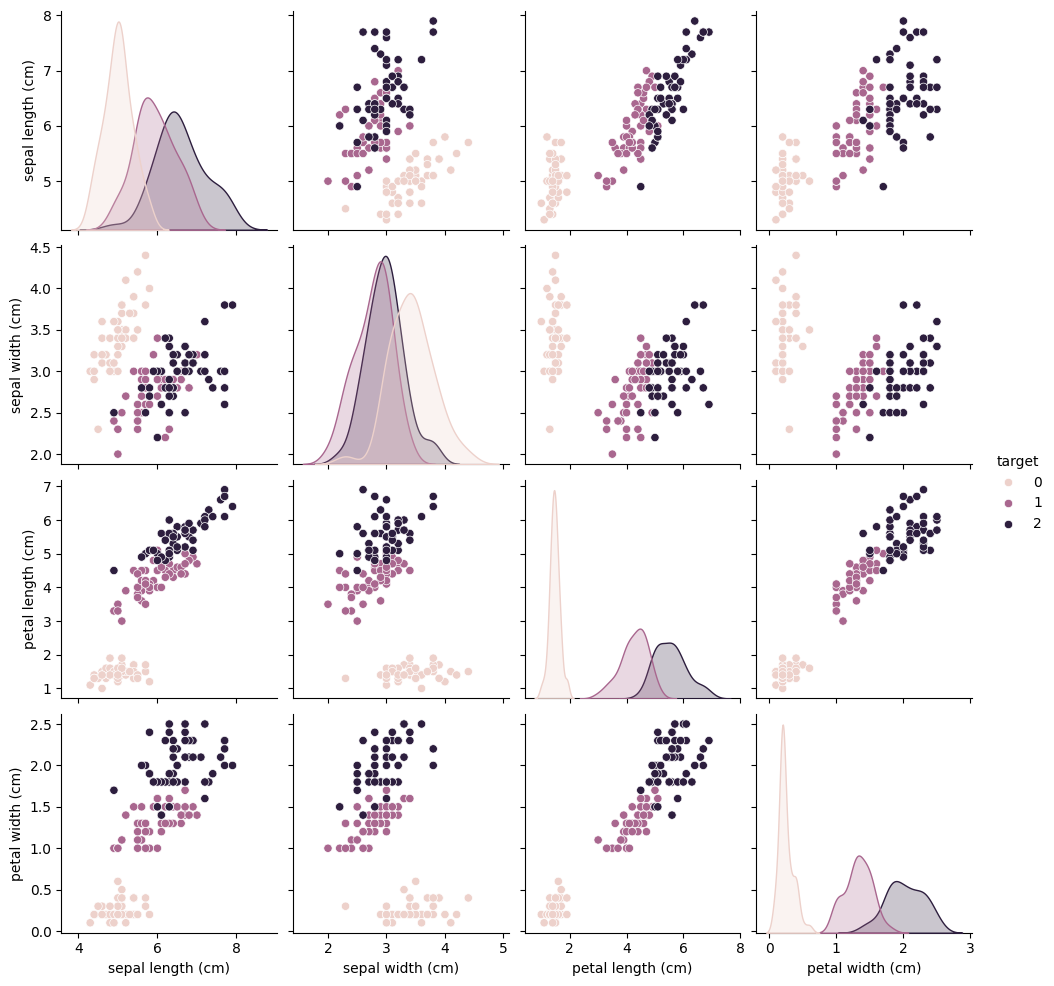

In [ ]:
sns.pairplot(iris, hue='target')

In [ ]:
x = pd.DataFrame(data.data, columns=data.feature_names)
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y = pd.DataFrame(data.target, columns=['target'])
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [ ]:
x.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
x.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [ ]:
x.duplicated().sum()

np.int64(1)

In [ ]:
# x.drop_duplicates(inplace=True)

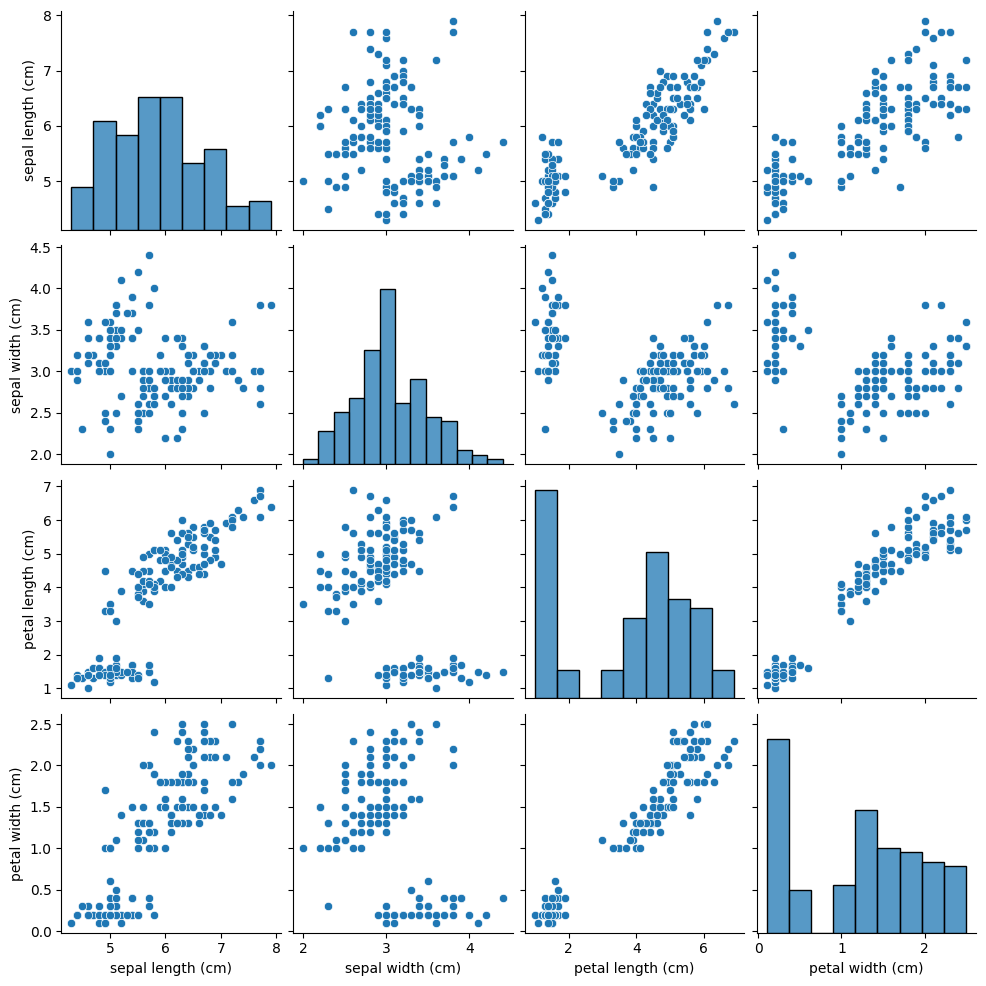

In [ ]:
sns.pairplot(x)

<Axes: >

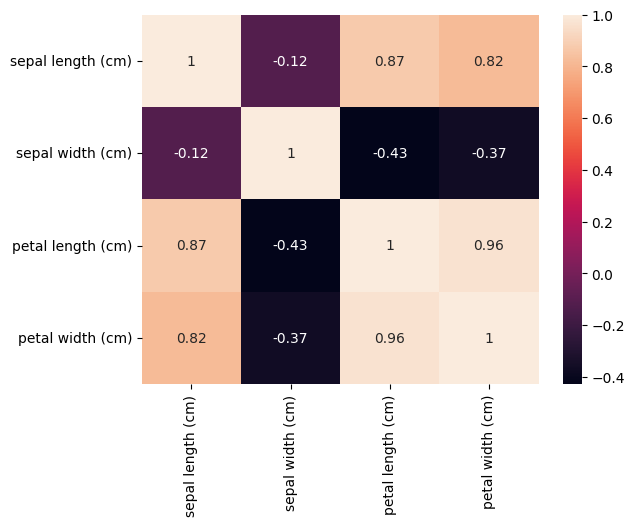

In [ ]:
sns.heatmap(x.corr(), annot=True)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

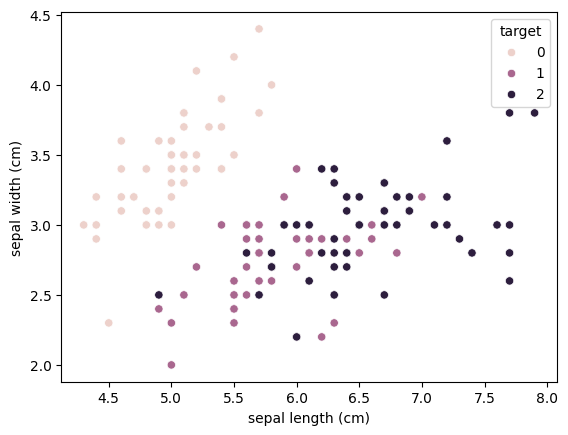

In [ ]:
sns.scatterplot(x=x['sepal length (cm)'], y=x['sepal width (cm)'], hue=y['target'])

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()
X = sc.fit_transform(x)

In [ ]:
inertia = []

for k in range(1,10):
  kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

Text(0, 0.5, 'Inertia')

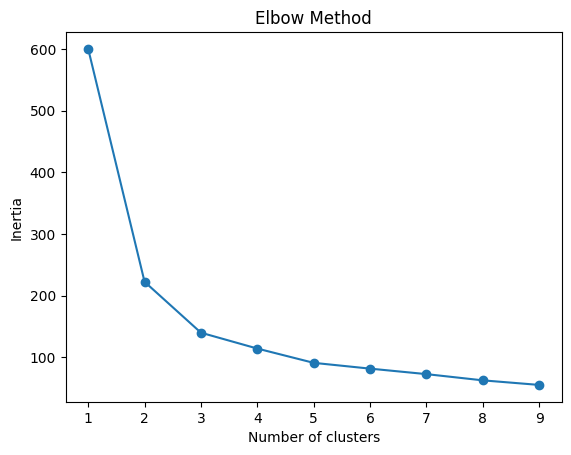

In [ ]:
plt.plot(range(1,10), inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [ ]:
sil_score = []
K_range = range(2,10)
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
  kmeans.fit(X)
  sil_score.append(silhouette_score(
      X, kmeans.predict(X)))

Text(0, 0.5, 'Silhouette Score')

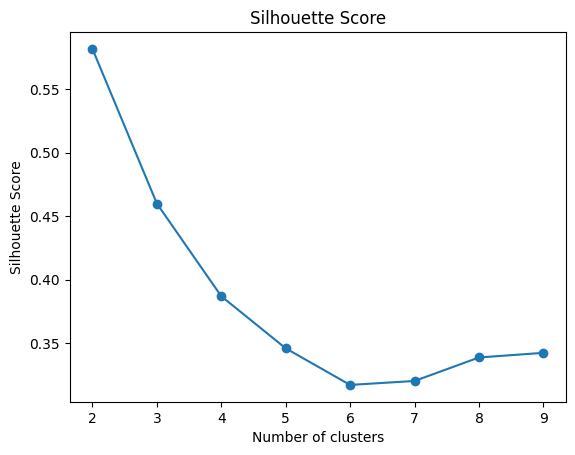

In [ ]:
plt.plot(K_range, sil_score,marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

In [ ]:
best_k = K_range[sil_score.index(max(sil_score))]
best_k

2

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=0)
y_pred = kmeans.fit(X)

In [ ]:
x['Cluster'] = kmeans.predict(X)

x

NameError: name 'X' is not defined

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)

In [ ]:
centers = kmeans.cluster_centers_

In [ ]:
centers_pca = pca.transform(centers)

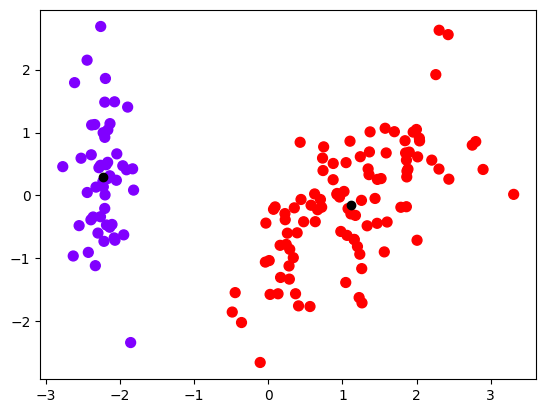

In [ ]:
plt.scatter(x_pca[:,0], x_pca[:,1], c=x['Cluster'], cmap='rainbow',s=50)
plt.scatter(centers_pca[:,0], centers_pca[:,1], color='black')

# Mall Customers

4 clusters min

premium
careful


In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [ ]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.drop('CustomerID', axis=1, inplace=True)

In [ ]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [ ]:
en = LabelEncoder()

df['Genre'] = en.fit_transform(df['Genre'])

In [ ]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [ ]:
df.isna().sum()

,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

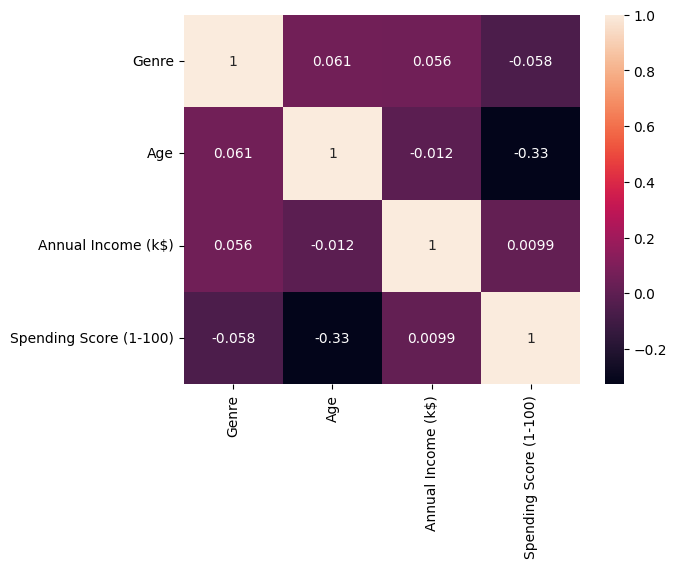

In [ ]:
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

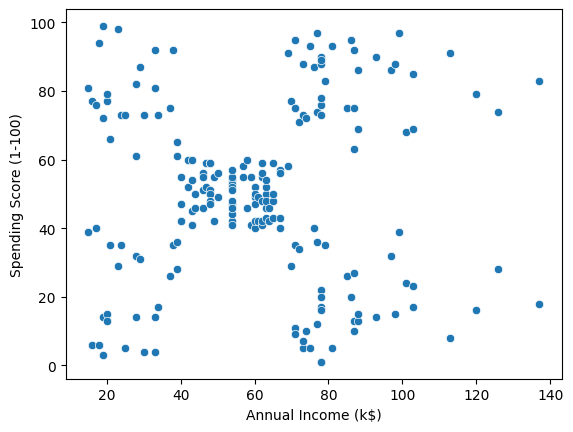

In [ ]:
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'])

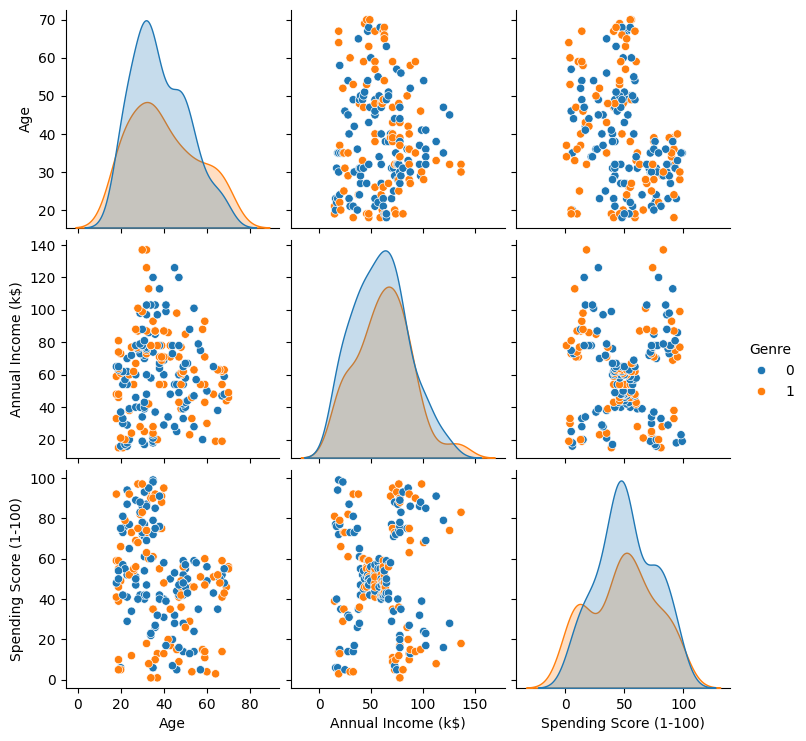

In [ ]:
sns.pairplot(df,hue='Genre')

In [ ]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


<Axes: xlabel='Age', ylabel='Count'>

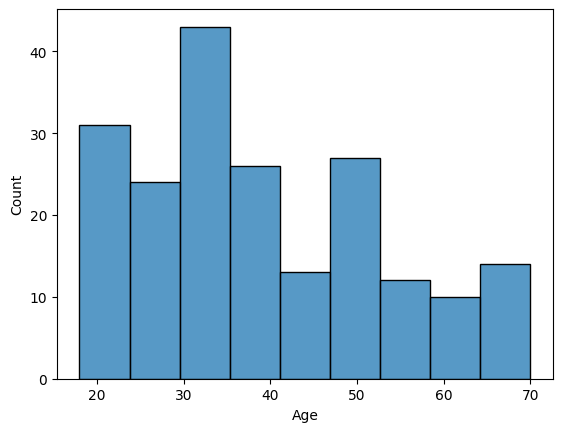

In [ ]:
sns.histplot(df['Age'])

In [ ]:
df = df.drop('Genre', axis=1)


In [ ]:
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [ ]:
sc = StandardScaler()
X = sc.fit_transform(df)

In [ ]:
inertia = []

for k in range(1,10):
  kmeans = KMeans(n_clusters=k, random_state=0,n_init=10)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

Text(0, 0.5, 'Inertia')

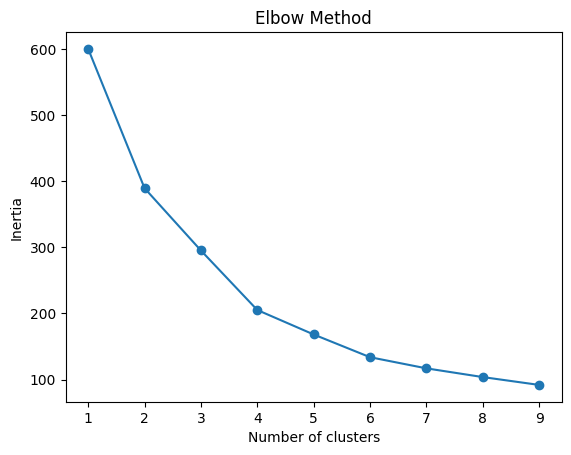

In [ ]:
plt.plot(range(1,10), inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [ ]:
sil_score = []
K_range = range(2,10)
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=0,n_init=10)
  kmeans.fit(X)
  sil_score.append(silhouette_score(
      X, kmeans.predict(X)))


Text(0, 0.5, 'Silhouette Score')

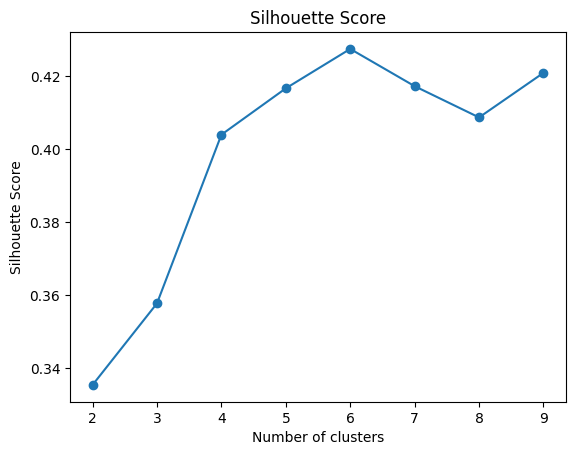

In [ ]:
plt.plot(K_range, sil_score,marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

In [ ]:
best_k = K_range[sil_score.index(max(sil_score))]
best_k

6

In [ ]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)

In [ ]:
k_means = KMeans(n_clusters=5, random_state=0,n_init=10)
y_pred = k_means.fit(X)

In [ ]:
center = k_means.cluster_centers_

In [ ]:
center_pca = pca.transform(center)

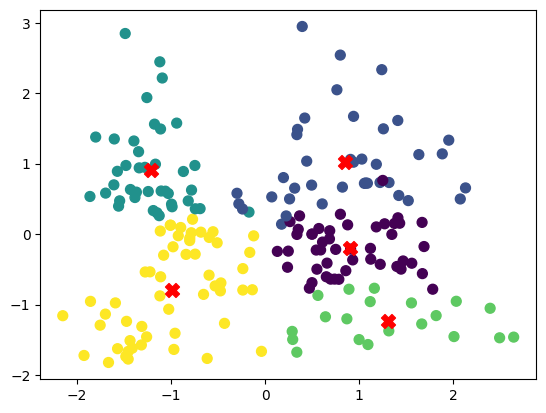

In [ ]:
plt.scatter(x_pca[:,0], x_pca[:,1], c=k_means.predict(X), cmap='viridis',s=50)
plt.scatter(center_pca[:,0], center_pca[:,1], color='red',s=100,marker='X')

In [ ]:
df1 = df.drop('Age',axis=1)

### Clustering on df1 (Annual Income vs Spending Score)

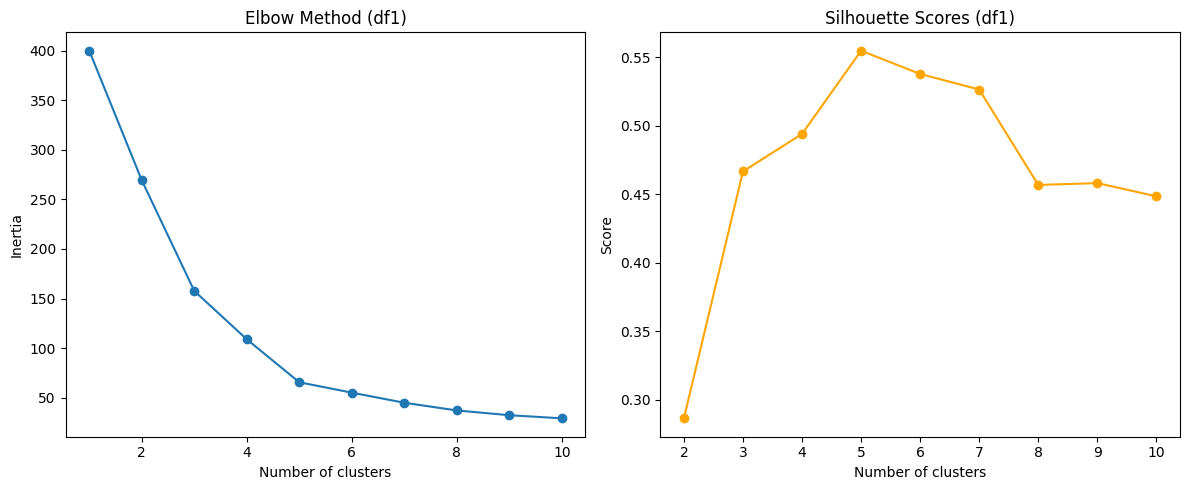

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Scaling df1
sc_df1 = StandardScaler()
X1 = sc_df1.fit_transform(df1)

# Elbow Method for df1
inertia1 = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X1)
    inertia1.append(km.inertia_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia1, marker='o')
plt.title('Elbow Method (df1)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

# Silhouette Score for df1
sil_scores1 = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X1)
    sil_scores1.append(silhouette_score(X1, labels))

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores1, marker='o', color='orange')
plt.title('Silhouette Scores (df1)')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

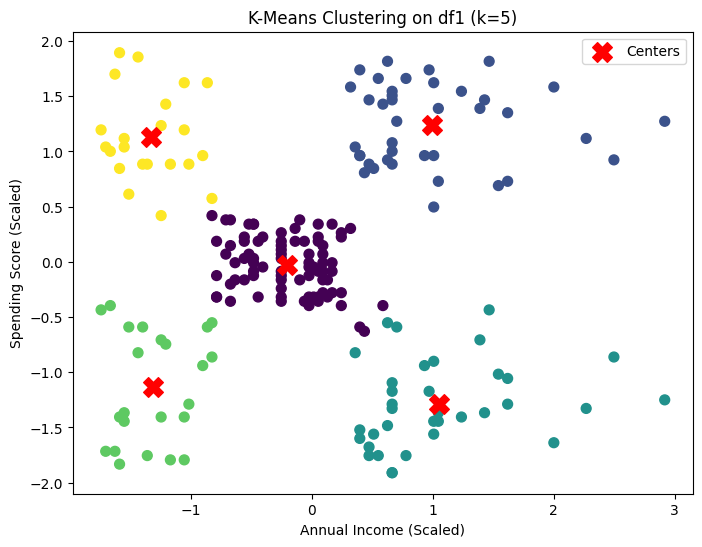

In [ ]:
# Based on typical Mall Customer analysis, k=5 is often the 'natural' fit for Income vs Score
best_k_df1 = 5
km_df1 = KMeans(n_clusters=best_k_df1, random_state=0, n_init=10)
y_df1 = km_df1.fit_predict(X1)

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], c=y_df1, cmap='viridis', s=50)
centers1 = km_df1.cluster_centers_
plt.scatter(centers1[:, 0], centers1[:, 1], color='red', s=200, marker='X', label='Centers')
plt.title(f'K-Means Clustering on df1 (k={best_k_df1})')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score,accuracy_score

In [ ]:
iris = load_iris(as_frame=True)

In [ ]:
df = iris.frame

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
# hirearchicial clusering

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
X = df.drop('target',axis=1)
model = linkage(X, method='ward')

{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [15.0, 15.0, 30.0, 30.0],
  [55.0, 55.0, 65.0, 65.0],
  [45.0, 45.0, 60.0, 60.0],
  [22.5, 22.5, 52.5, 52.5],
  [5.0, 5.0, 37.5, 37.5],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [75.0, 75.0, 92.5, 92.5],
  [135.0, 135.0, 145.0, 145.0],
  [125.0, 125.0, 140.0, 140.0],
  [115.0, 115.0, 132.5, 132.5],
  [83.75, 83.75, 123.75, 123.75],
  [21.25, 21.25, 103.75, 103.75],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [175.0, 175.0, 192.5, 192.5],
  [165.0, 165.0, 183.75, 183.75],
  [155.0, 155.0, 174.375, 174.375],
  [62.5, 62.5, 164.6875, 164.6875],
  [215.0, 215.0, 225.0, 225.0],
  [245.0, 245.0, 255.0, 255.0],
  [235.0, 235.0, 250.0, 250.0],
  [265.0, 265.0, 275.0, 275.0],
  [295.0, 295.0, 305.0, 305.0],
  [285.0, 285.0, 300.0, 300.0],
  [270.0, 270.0, 292.5, 292.5],
  [242.5, 242.5, 281.25, 281.25],
  [220.0, 220.0, 261.875, 261.875],
  [325.0, 325.0, 335.0, 335.0],
  [315.0, 315.0, 330.0, 330.0],
  [365.0, 36

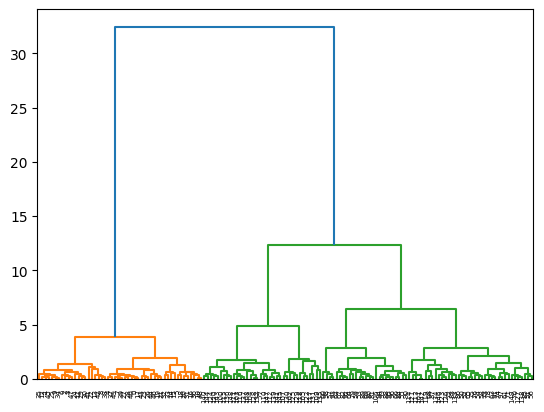

In [ ]:
dendrogram(model)

In [ ]:
agg = AgglomerativeClustering(n_clusters=3)
y_pred = agg.fit_predict(X)

In [ ]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)

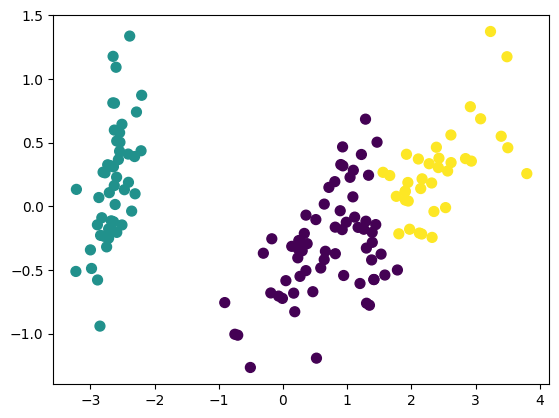

In [ ]:
plt.scatter(x_pca[:,0], x_pca[:,1], c=y_pred, cmap='viridis',s=50)

In [ ]:
a = [1,2,[3,4,5,6]]
b = a

In [ ]:
a

[1, 2, [3, 4, 5, 6]]

In [ ]:
b

[1, 2, [3, 4, 5, 6]]

In [ ]:
b[2][0] = 7

In [ ]:
b

[1, 2, [7, 4, 5, 6]]

In [ ]:
a

[1, 2, [7, 4, 5, 6]]